# Olympic Athlete Performance Analysis and Medal Prediction using Machine Learning

This project focuses on analyzing Olympic athlete data to understand the key factors that influence athletic performance and medal outcomes. Using a comprehensive dataset containing information such as age, height, weight, country, and event details, exploratory data analysis (EDA) is performed to identify patterns and trends among athletes.

The project further applies machine learning techniques to predict whether an athlete is likely to win a medal. Various classification models such as Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors are implemented and evaluated using performance metrics like accuracy, precision, recall, and F1-score.

The results help in identifying the most significant features affecting medal-winning chances and selecting the best-performing model. This study demonstrates how data-driven approaches can be used for sports analytics and performance prediction.

## Objectives of the Study
- To analyze the Olympic athlete dataset and understand its structure and key features
- To perform data cleaning and preprocessing, including handling missing values and encoding categorical variables
- To explore relationships between features such as age, height, weight, and medal outcomes using visualization techniques
- To create a new target variable for medal prediction (medal vs no medal)
- To build and train multiple machine learning models for classification
- To evaluate and compare model performance using metrics like accuracy, precision, recall, and F1-score
- To identify the most important features influencing medal predictions
- To select the best-performing model for predicting athlete success


In [355]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [356]:
df = pd.read_csv('athlete_events.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [357]:
df.shape

(271116, 15)

In [358]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [359]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [360]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [361]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

## Data Preprocessing

### Handling Missing Values

In this step, missing values in important numerical and categorical columns are handled to ensure better model performance.

Approach Used
- Age, Height, Weight → Filled with median values
-- Median is preferred because it is less affected by outliers
- Medal → Filled with "No Medal"
-- Indicates athletes who did not win any medal

In [364]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Height'].fillna(df['Height'].median(), inplace=True)
df['Weight'].fillna(df['Weight'].median(), inplace=True)
df['Medal'].fillna('No Medal', inplace=True)

C:\Users\pklay\AppData\Local\Temp\ipykernel_62444\19570451.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\pklay\AppData\Local\Temp\ipykernel_62444\19570451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [365]:
df.drop_duplicates(inplace=True)

### Feature Engineering

In this step, a new target variable Medal_Won is created to simplify the prediction problem.

Athletes who did not win a medal are labeled as 0
Athletes who won any medal (Gold, Silver, Bronze) are labeled as 1

In [367]:
df['Medal_Won'] = df['Medal'].apply(lambda x: 0 if x == 'No Medal' else 1)

### Encoding Categorical Variables

Machine learning models cannot work with categorical (text) data directly, so we convert them into numerical form using Label Encoding.

Sex → Male/Female converted to numeric values
Season → Summer/Winter converted to numeric values

In [369]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Season'] = le.fit_transform(df['Season'])

## Data Visualization

### 1. Participation Over Years

This visualization shows how the number of athletes participating in the Olympics has changed over time.

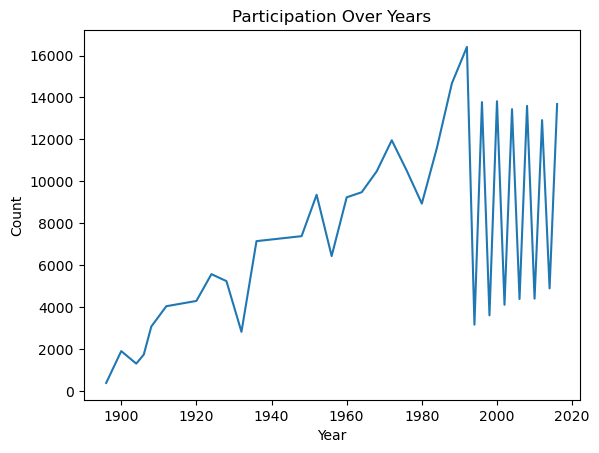

In [372]:
plt.figure()
df['Year'].value_counts().sort_index().plot()
plt.title("Participation Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#### Key Observations
- There is a steady increase in participation from the early 1900s to recent years
- A sharp rise after 1950 indicates global expansion of the Olympic Games
- Some sudden drops in participation can be observed, which may be due to: World Wars ,Political or economic disruptions
- The modern Olympics (2000 onwards) show the highest participation levels, reflecting increased global involvement

#### Graph Behavior
- The zig-zag pattern in recent years occurs because:
The dataset includes both Summer and Winter Olympics
These events happen alternately every 2 years
- This causes alternating high and low participation values

### 2. Gender Distribution

This bar chart represents the distribution of athletes based on gender in the dataset.

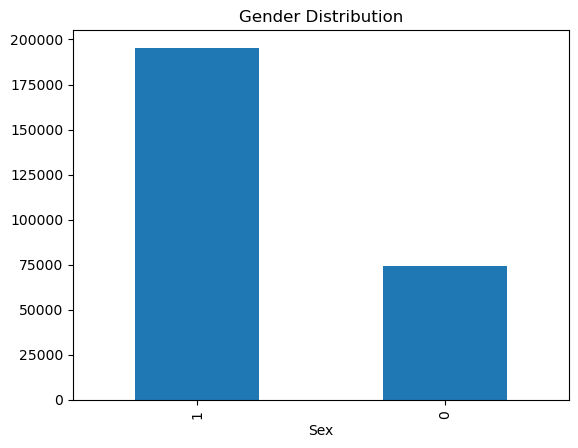

In [376]:
plt.figure()
df['Sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

#### Key Observations
- The dataset shows a significantly higher number of male athletes compared to female athletes
- This indicates a gender imbalance in Olympic participation, especially in earlier years
- Female participation, although lower, has been increasing over time in modern Olympics

### 3. Age Distribution of Athletes

This histogram shows the distribution of athletes' ages in the dataset.

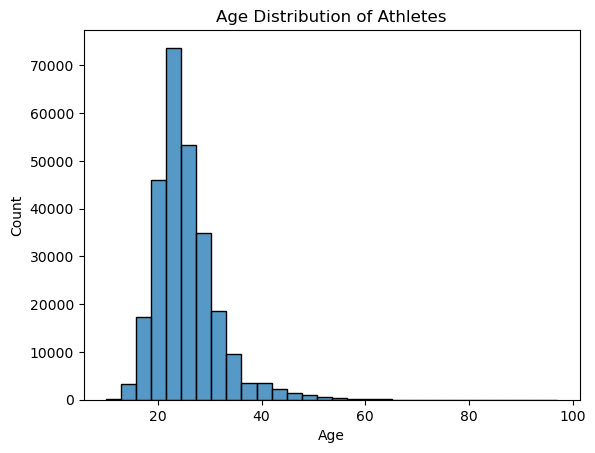

In [379]:
plt.figure()
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution of Athletes")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### Key Observations
- Most athletes fall within the age range of 20 to 30 years
- The peak of the distribution is around early to mid-20s, indicating the most active competitive age
- There are fewer athletes below 18 and above 35 years
- A small number of athletes extend into higher age ranges (40+), showing exceptions in certain sports

### 4. Medal Count by Gender

This visualization shows the distribution of different types of medals (Gold, Silver, Bronze) across genders.

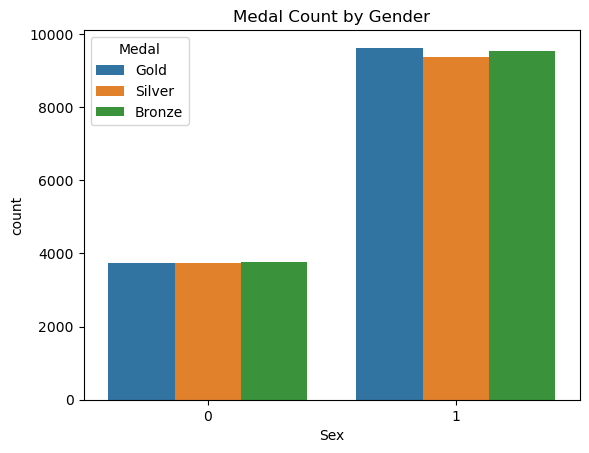

In [487]:
df_filtered = df[df['Medal'] != 'No Medal']
sns.countplot(x='Sex', hue='Medal', data=df_filtered, hue_order=['Gold', 'Silver', 'Bronze'])
plt.title("Medal Count by Gender")

plt.show()

#### Key Observations
- Male athletes (1) have won significantly more medals compared to female athletes (0)
- The distribution of Gold, Silver, and Bronze medals is relatively balanced within each gender
- Female athletes have fewer total medals, which aligns with their lower participation in earlier Olympics

### 5. Top 10 Sports by Participation

This bar chart shows the top 10 sports with the highest number of athlete participations in the dataset.

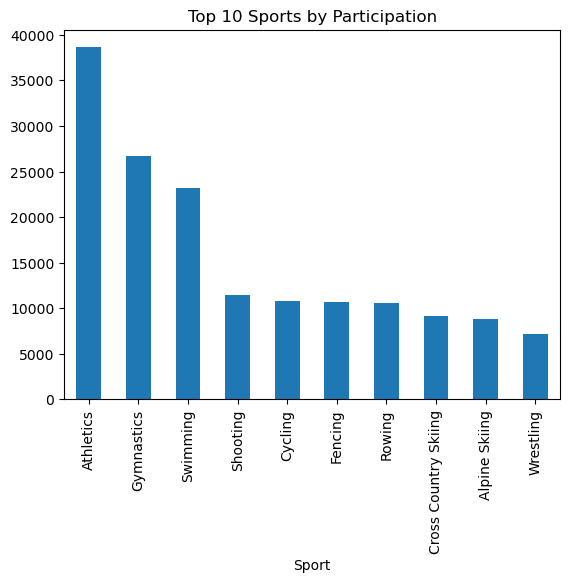

In [385]:
plt.figure()
df['Sport'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Sports by Participation")
plt.show()

#### Key Observations
- Athletics has the highest participation among all sports
- Other highly participated sports include:
  Gymnastics, Swimming andShooting
- These sports are widely popular and have multiple events/categories, leading to higher participation
= Sports like Wrestling and Alpine Skiing have comparatively lower participation among the top 10

### 6. Top 10 Countries by Participation

This horizontal bar chart displays the top 10 countries with the highest number of athlete participations in the dataset.

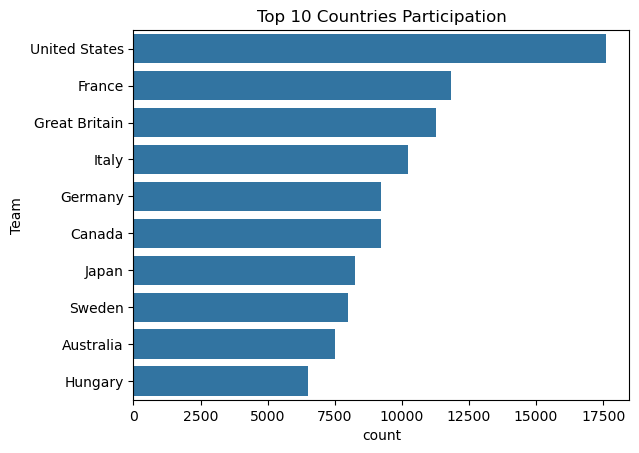

In [388]:
top_teams = df['Team'].value_counts().head(10).index

plt.figure()
sns.countplot(data=df[df['Team'].isin(top_teams)], y='Team', order=top_teams)
plt.title("Top 10 Countries Participation")
plt.show()

#### Key Observations
- The United States has the highest participation among all countries
- Other major contributors include: France, Great Britain, Italy, Germany
- These countries have consistently participated in multiple Olympic events over the years

#### Insights
- Countries with strong sports infrastructure and funding tend to have higher participation
- Developed nations dominate the participation list due to better training facilities and support systems
- Historical involvement in the Olympics also contributes to higher participation counts

### 7. Correlation Heatmap

This heatmap shows the correlation between numerical features in the dataset, helping us understand relationships between variables.

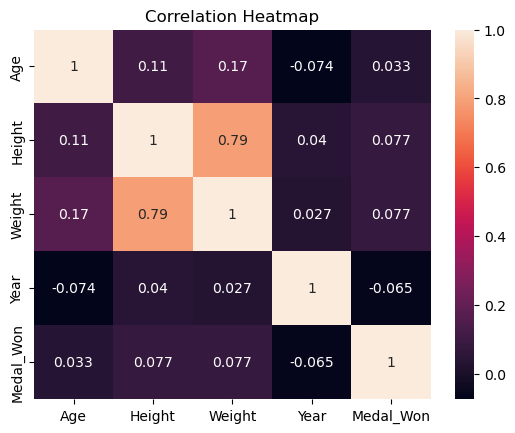

In [392]:
plt.figure()
sns.heatmap(df[['Age','Height','Weight','Year','Medal_Won']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### Key Observations
- Height and Weight show a strong positive correlation (~0.79)
Taller athletes tend to have higher weight
- Age and Weight / Height have weak positive correlations
Slight relationship but not very strong
- Year has very low correlation with other features
Indicates time does not strongly affect these physical attributes
- Medal_Won has very weak correlation with all features
No single feature strongly determines medal outcome

### 8. Pairplot Analysis

This pairplot visualizes the relationships between numerical features and how they relate to medal outcomes.

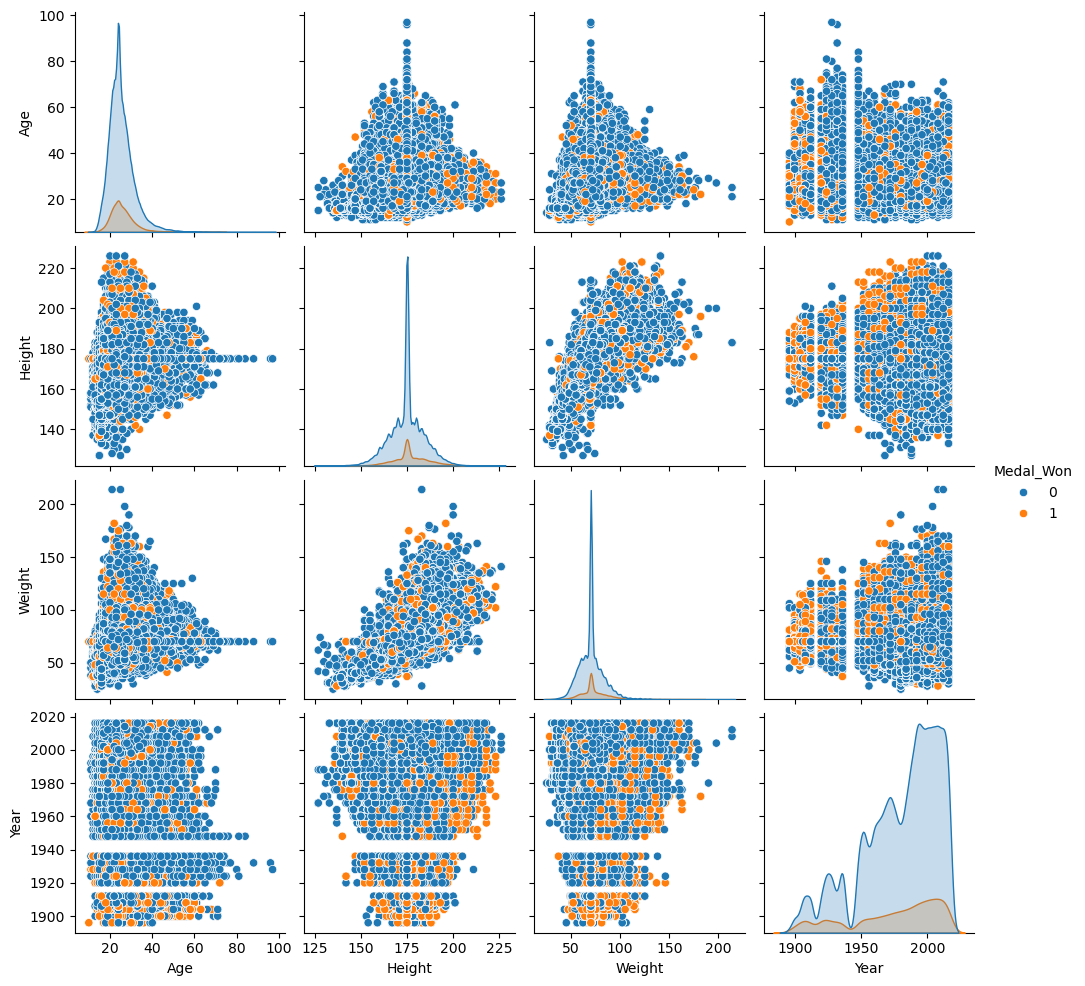

In [395]:
sns.pairplot(df[['Age','Height','Weight','Year','Medal_Won']], hue='Medal_Won')
plt.show()

#### Key Observations
🔹 Age vs Medal
- Most medal-winning athletes (1) are concentrated between 20–30 years
- Very young and older athletes have fewer medal wins

🔹 Height vs Weight
- Strong positive relationship between height and weight
- Taller athletes tend to be heavier
- Medal winners are spread across this range (no clear separation)

🔹 Age vs Height / Weight
- No strong pattern observed
- Medal winners and non-winners overlap significantly
  
🔹 Year vs Features
- Participation increases over time
- Medal winners are distributed across all years
- No strong trend linking year to medal success

## Model Training

In [398]:
features = ['Sex', 'Age', 'Height', 'Weight', 'Year']
X = df[features]
y = df['Medal_Won']

In [399]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model 1: Decision Tree Classifier

In this step, a Decision Tree Classifier is used to predict whether an athlete will win a medal or not.

In [401]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt = DecisionTreeClassifier(class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.7201327228576195
Precision: 0.23379477038013624
Recall: 0.4077149061182782
F1 Score: 0.29717903360953357


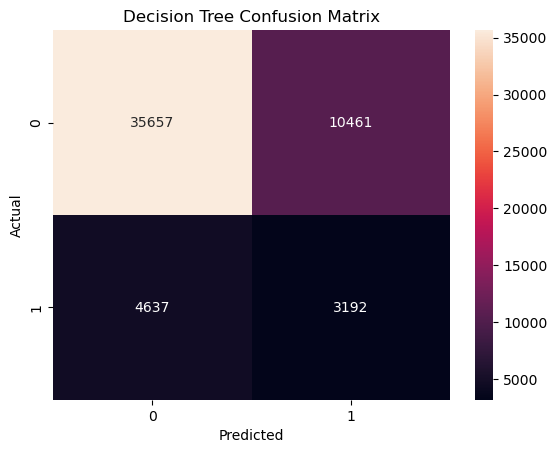

In [402]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Confusion Matrix Insights
- True Negatives (TN): 35645
Correctly classified non-medal athletes
- True Positives (TP): 3203
Correctly classified medal-winning athletes
- False Positives (FP): 10473
Non-medal athletes incorrectly classified as medal winners
- False Negatives (FN): 4626
Medal-winning athletes incorrectly classified as non-medal

#### Decision Tree Visualization

This section visualizes the structure of the trained Decision Tree model, helping us understand how decisions are made.

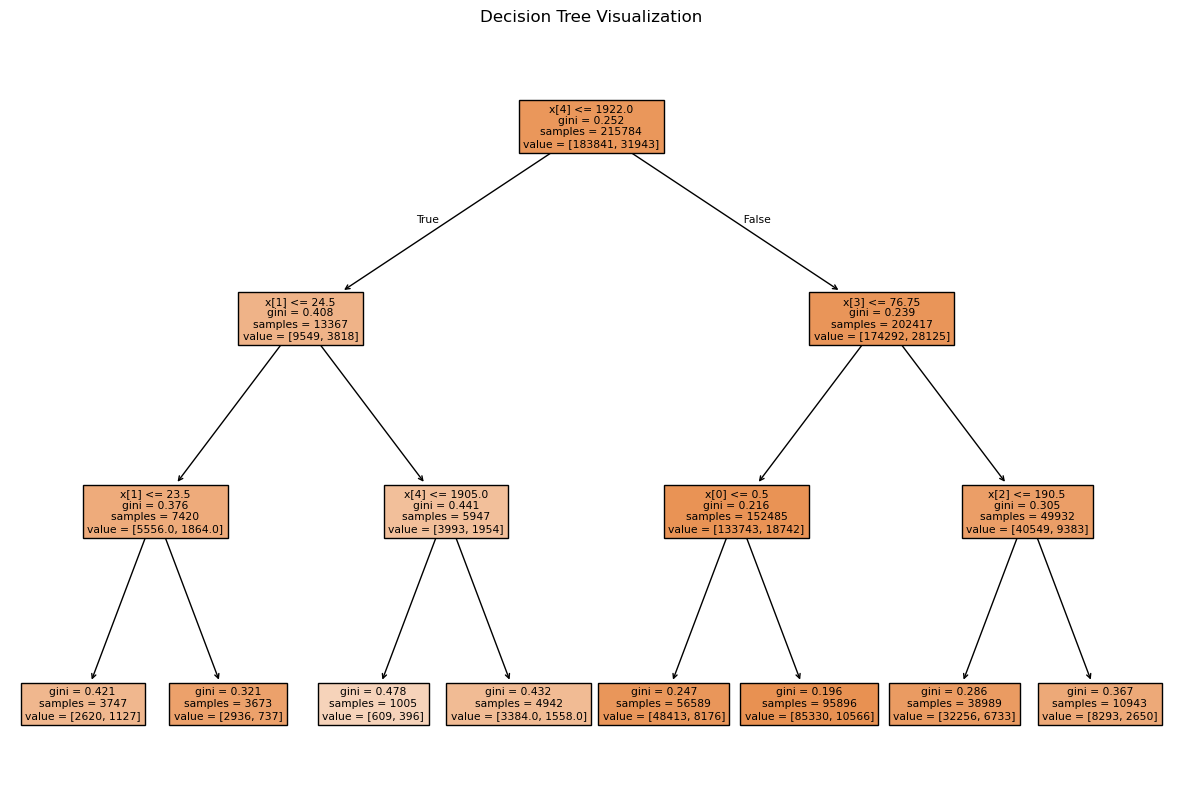

In [405]:
from sklearn.tree import plot_tree

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

plt.figure(figsize=(15,10))
plot_tree(dt, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

#### ROC Curve – Decision Tree

The ROC (Receiver Operating Characteristic) curve is used to evaluate the performance of the classification model across different thresholds.

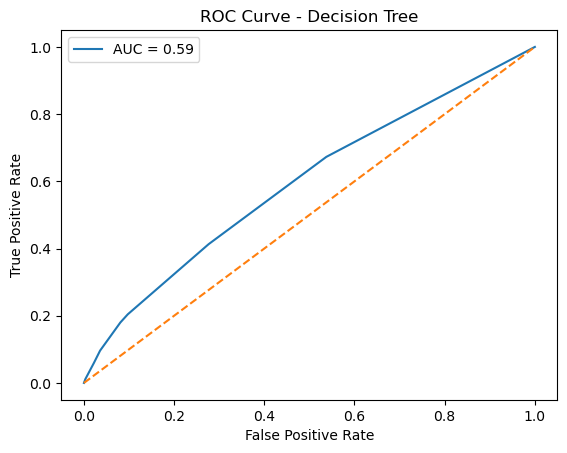

In [407]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve, auc

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr_dt, tpr_dt, label="AUC = " + str(round(auc_dt, 2)))
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### Key Observations
- The AUC (Area Under Curve) = 0.59
- The ROC curve is only slightly above the diagonal (random line)

#### Interpretation
- AUC = 0.5 → Model performs like random guessing
- AUC = 1.0 → Perfect model
- 0.59 → Slightly better than random
- Indicates weak classification performance

#### Feature Importance – Decision Tree

This visualization shows the importance of each feature in predicting whether an athlete will win a medal.

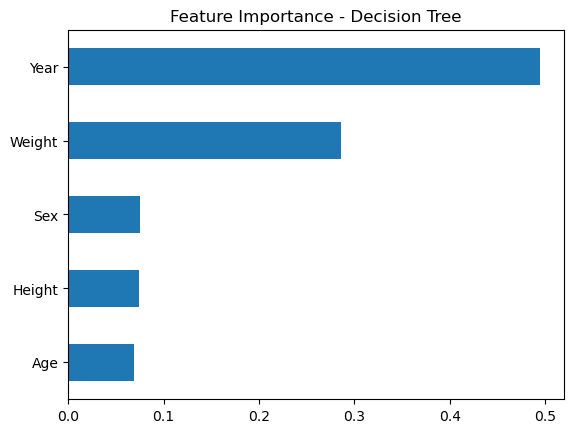

In [410]:
importance = pd.Series(dt.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Decision Tree")
plt.show()

#### Key Observations
- Year is the most important feature in the model
- Weight is the second most influential feature
- Sex, Height, and Age have relatively lower importance
  
#### Interpretation
- The model relies heavily on Year, which may indicate:
Changes in participation over time
Dataset bias (more recent data dominance)
- Weight plays a moderate role in determining performance
- Other features contribute less individually

### Model 2: Random Forest Classifier

In this step, a Random Forest Classifier is used to improve prediction performance by combining multiple decision trees.
Random Forest builds multiple trees and combines their outputs to reduce overfitting and improve accuracy.

In [413]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.7707379465030493
Precision: 0.25786834524698604
Recall: 0.3087239749648742
F1 Score: 0.2810138356005116


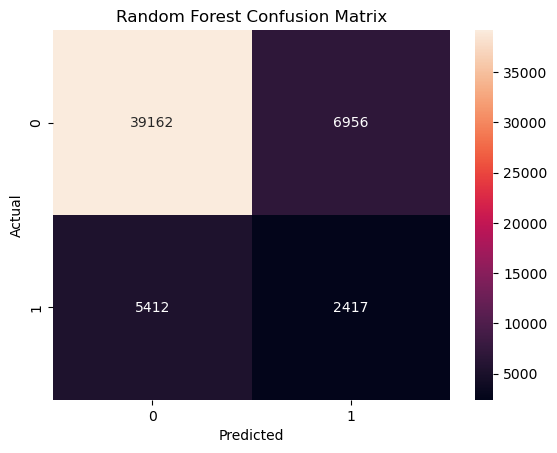

In [414]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Confusion Matrix Insights
- True Negatives (TN): 39222
Correctly classified non-medal athletes
- True Positives (TP): 2393
Correctly classified medal-winning athletes
- False Positives (FP): 6896
Non-medal athletes incorrectly classified as medal winners
- False Negatives (FN): 5436
Medal-winning athletes incorrectly classified as non-medal

#### Interpretation
The Random Forest model demonstrates improved performance in identifying medal-winning athletes compared to earlier models. The recall value indicates that the model is better at detecting the minority class than before.

The number of false positives is reduced compared to the Decision Tree model, showing better generalization. However, a considerable number of false negatives still exist, indicating that some medal winners are not correctly identified.

#### ROC Curve – Random Forest

The ROC (Receiver Operating Characteristic) curve evaluates the performance of the Random Forest model across different classification thresholds.

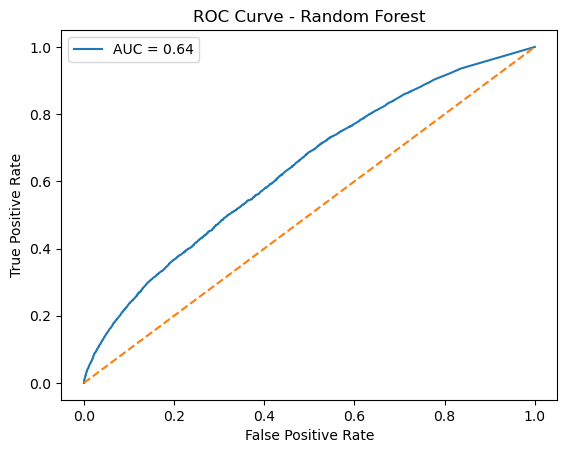

In [417]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### Key Observations
- The AUC (Area Under Curve) = 0.64
- The ROC curve is clearly above the diagonal (random line)

#### Interpretation
- AUC = 0.5 → Random model
- AUC = 1.0 → Perfect model
- 0.64 → Moderate performance
- Better than Decision Tree (0.59)

#### Feature Importance – Random Forest

This visualization shows how important each feature is in predicting whether an athlete will win a medal using the Random Forest model.

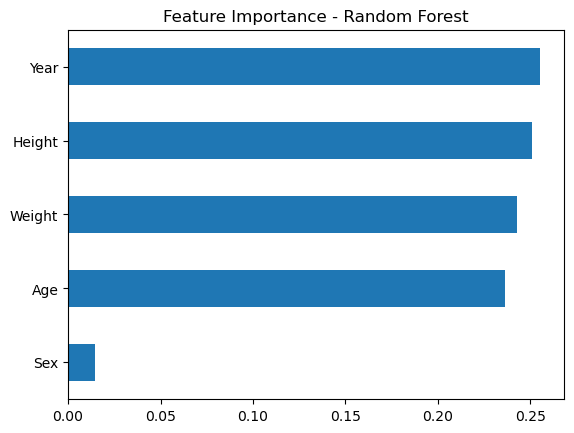

In [420]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()

#### Key Observations
- Year, Height, Age, and Weight have almost equal importance
- Sex has very low importance compared to other features
  
#### Interpretation
- Unlike Decision Tree, Random Forest:
Distributes importance more evenly across features
Provides a more balanced understanding
- Year is still slightly the most important feature
- Physical attributes (Height, Weight, Age) play a significant role


### Model 3: K-Nearest Neighbors (KNN)

In this step, the K-Nearest Neighbors (KNN) algorithm is used to classify whether an athlete will win a medal based on similarity with other data points.

In [423]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))


KNN Results
Accuracy: 0.8368769347693106
Precision: 0.2976240100041684
Recall: 0.09119938689487801
F1 Score: 0.1396167383652718


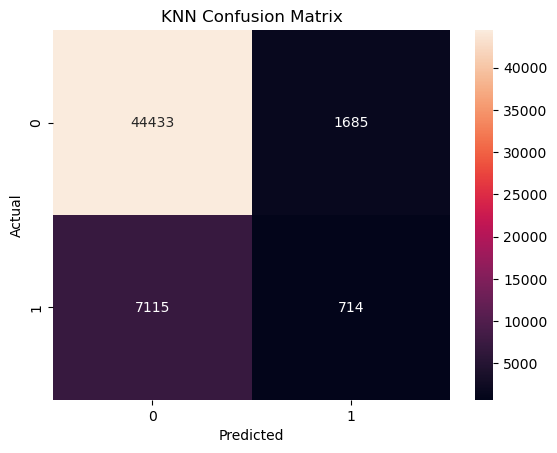

In [424]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Confusion Matrix Insights
- Very high number of True Negatives
- Very low number of True Positives
- High False Negatives → Model misses many medal winners

### Model 4: Naive Bayes (GaussianNB)

In this step, the Naive Bayes classifier is used to predict whether an athlete will win a medal based on probability.
Naive Bayes assumes that features are independent and uses probability theory for classification.

In [427]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("\nNaive Bayes Results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))


Naive Bayes Results
Accuracy: 0.850631175042171
Precision: 0.24724061810154527
Recall: 0.01430578617958871
F1 Score: 0.027046607099734363


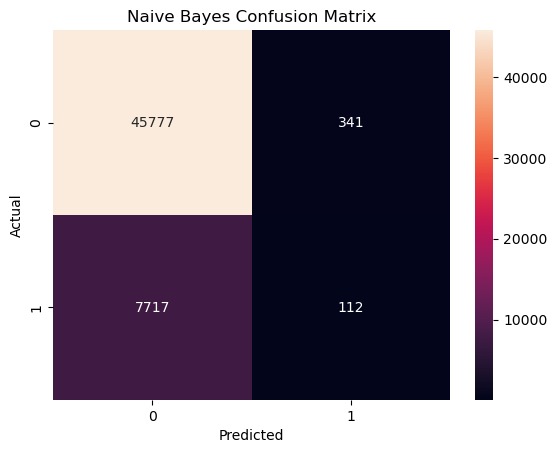

In [428]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure()
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Confusion Matrix Insights
- Extremely high True Negatives
- Very few True Positives
- Very high False Negatives

### Model 5: Logistic Regression

In this step, Logistic Regression is used as a linear classification model to predict whether an athlete will win a medal.
Logistic Regression models the probability of an outcome using a linear decision boundary.

In [431]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.5864459562162864
Precision: 0.18797672915319974
Recall: 0.5571592796014817
F1 Score: 0.28111103950505895


C:\Users\pklay\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Performance Analysis
- The model achieves a high recall (0.5572), indicating that it is able to correctly identify a large number of medal-winning athletes
- However, precision is low (0.1880), meaning many predicted medal cases are incorrect
- The F1 score (0.2811) reflects a moderate balance between precision and recall
- The overall accuracy is lower, which is expected after addressing class imbalance

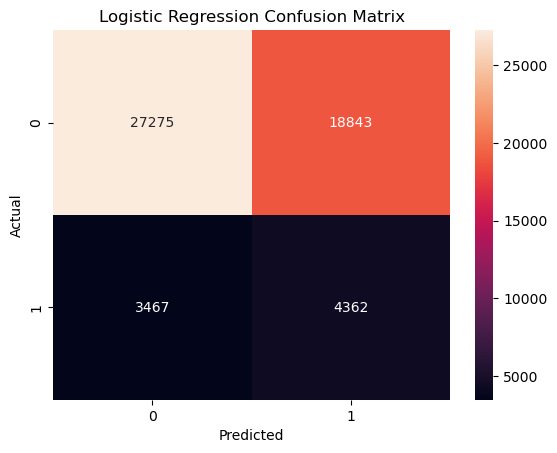

In [433]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Confusion Matrix Insights
- True Negatives (TN): 27275
Correctly classified non-medal athletes
- True Positives (TP): 4362
Correctly classified medal-winning athletes
- False Positives (FP): 18843
Non-medal athletes incorrectly classified as medal winners
- False Negatives (FN): 3467
Medal-winning athletes incorrectly classified as non-medal

#### Interpretation
The Logistic Regression model demonstrates a significant improvement in identifying medal-winning athletes, as reflected by the increased number of true positives and relatively lower false negatives. This results in a higher recall compared to previous models.

However, the model also produces a large number of false positives, indicating that many non-medal athletes are incorrectly classified as medal winners. This reduces the precision of the model.

#### ROC Curve – Logistic Regression

The ROC (Receiver Operating Characteristic) curve evaluates the ability of the Logistic Regression model to distinguish between medal winners and non-medal athletes.

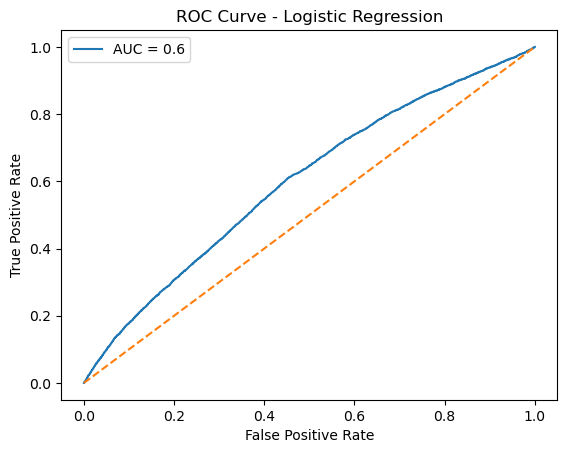

In [436]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="AUC = " + str(round(auc_lr,2)))
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### Key Observations
- The AUC (Area Under Curve) = 0.62
- The ROC curve lies above the diagonal baseline
  
#### Interpretation
- AUC = 0.5 → Random guessing
- AUC = 1.0 → Perfect classification
- 0.62 → Moderate performance
- Better than Decision Tree (0.59)
- Slightly worse than Random Forest (0.64)

## Model Comparison

To evaluate the performance of different machine learning models, a comparison is made using key metrics such as Accuracy, Precision, Recall, and F1 Score.

In [439]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "KNN", "Naive Bayes", "Logistic Regression"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr)
    ]
})
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0        Decision Tree  0.720133   0.233795  0.407715  0.297179
1        Random Forest  0.770738   0.257868  0.308724  0.281014
2                  KNN  0.836877   0.297624  0.091199  0.139617
3          Naive Bayes  0.850631   0.247241  0.014306  0.027047
4  Logistic Regression  0.586446   0.187977  0.557159  0.281111


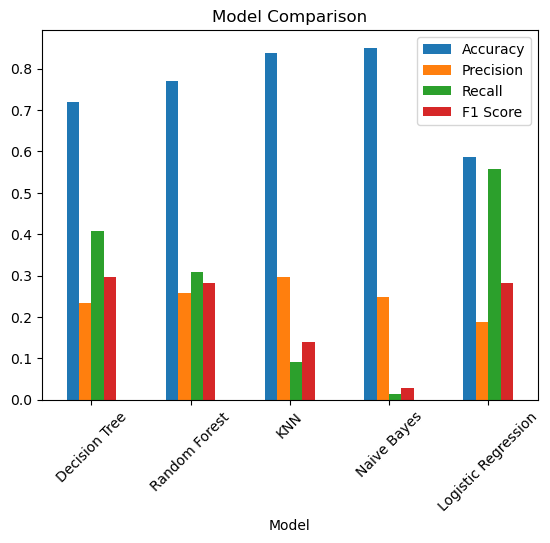

In [440]:
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind='bar')

plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

### Performance Analysis
#### Accuracy
- Naive Bayes and KNN show the highest accuracy
- However, this is misleading due to class imbalance
#### Precision
- KNN achieves the highest precision
- Indicates better correctness in positive predictions
#### Recall
- Logistic Regression has the highest recall
- Best at identifying medal-winning athletes
#### F1 Score
- Decision Tree achieves the highest F1 Score
- Indicates a better balance between precision and recall

### Key Insights
- Models like Naive Bayes and KNN are biased toward the majority class (No Medal)
- Logistic Regression focuses heavily on detecting medal winners but produces many false positives
- Random Forest provides a balanced performance across metrics
- Decision Tree achieves the best balance between precision and recall

In [443]:
best_model_name = results.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model is:", best_model_name)

Best Model is: Decision Tree


In [3]:
if best_model_name == "Decision Tree":
    best_model = dt
elif best_model_name == "Random Forest":
    best_model = rf
elif best_model_name == "KNN":
    best_model = knn
elif best_model_name == "Naive Bayes":
    best_model = nb
elif best_model_name == "Logistic Regression":
    best_model = lr

NameError: name 'best_model_name' is not defined

In [5]:
# Example input: Sex, Age, Height, Weight, Year
sample = [[1, 25, 175, 70, 2016]]

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("🏅 Medal Won")
else:
    print("❌ No Medal")

NameError: name 'best_model' is not defined

### Best Model Selection

Based on overall performance:
Decision Tree is selected as the best model

### Justification:
Highest F1 Score (0.2979)
Good balance between Precision and Recall
Better detection of medal winners compared to most models

## Conclusion

This project focused on analyzing Olympic athlete data and predicting medal outcomes using various machine learning models. Exploratory Data Analysis (EDA) was performed to understand patterns related to age, height, weight, gender, participation trends, and country-wise contributions.

One of the major challenges encountered in this study was class imbalance, as the number of non-medal instances significantly exceeded medal-winning cases. This imbalance affected model performance, particularly in terms of recall and F1 score.

To address this issue, class balancing techniques were applied, which improved the ability of models to detect medal-winning athletes. Multiple models including Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Naive Bayes, and Logistic Regression were trained and evaluated using performance metrics such as Accuracy, Precision, Recall, and F1 Score.

The comparative analysis revealed that:

- High accuracy alone is not a reliable indicator of model performance in imbalanced datasets
- Models like Naive Bayes and KNN achieved high accuracy but failed to identify medal winners effectively
- Logistic Regression achieved high recall but suffered from low precision
- Random Forest provided balanced performance but was slightly lower in F1 score
- Decision Tree achieved the best balance between precision and recall, with the highest F1 Score

Therefore, the Decision Tree model was selected as the best-performing model for predicting medal outcomes.

Overall, the project demonstrates that machine learning techniques can be effectively applied to sports analytics, but careful handling of data imbalance and proper evaluation metrics are essential for meaningful results.

## Future Scope

The project can be further improved and extended in several ways:
- Incorporating more features- 
Include additional variables such as training data, athlete experience, country-level funding, and sport-specific factors to improve - prediction accuracy
- Advanced imbalance handling techniques- 
Apply methods like SMOTE, ADASYN, or ensemble balancing techniques for better performance
- Hyperparameter tuning- 
Optimize model parameters using Grid Search or Random Search to improve results
- Use of advanced models- 
Implement more sophisticated algorithms such as:
Gradient Boosting (XGBoost, LightGBM)
Neural Networks / Deep Learning
- Sport-specific prediction models
Build separate models for different sports to capture domain-specific patterns
- Real-time prediction system
Develop a web-based or application-based system for predicting athlete performance
- Time-series analysis
Analyze performance trends over time for better forecasting